
## Department of Mathematics <br> College of Arts and Sciences, Howard University<br>Math 014 (01) - Introduction to Data Science<br>Project 2 <br>
### Student Name: Monique Bucknor       //       Due date: 04-18-2025<br> Student ID: @03133387


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### I. Dataset Overview & Structure: 
The selected dataset contains an overview of data collected for the 2017 **Ultimate Halloween Candy Power Ranking** summarizing the compositions of 85 marketplace candies as well as comparing the sugar, price, and preferability between all of the candies. The compositional data contained information such as if the candies contained chocolate, caramel, fruit flavoring, as well as within-subject data, comparing the sugar percentage, price percentage, and overall "win" percentage (*Meaning the overall rate of preference over other candies within the researcher's survey. Specifically, participants were shown pairs of candies and asked to choose their favorite.*).

The variables are listed below: 

**Categorical Data**:
* chocolate (bool to int)
* fruity (bool to int)
* caramel (bool to int)
* peanutalmondy (bool to int)
* nougat (bool to int)
* crispedricewafer (bool to int)
* hard (bool to int)
* bar (bool to int)
* pluribus {"Is it one of many candies in a bag or box"} (bool to int)

**Numerical Data**:
* sugarpercent
* pricepercent
* winpercent

The basic shape and structure of the dataset is shown below:

In [4]:
# Read the shape of dataset
df = pd.read_csv(r"C:\Users\pfmij\In_Class_Assignments\Monique_Bucknor_March_28\candy-data.csv")
print(f"The data's shape is {df.shape}")

The data's shape is (85, 13)


In [5]:
# Providing names for groupby
chocolate = 'chocolate'
fruity = 'fruity'
caramel = 'caramel'
nuts = 'peanutalmondy'
nougat = 'nougat'
crispedricewafer = 'crispedricewafer'
hard = 'hard'
bar = 'bar'
pluribus = 'pluribus'
sugarpercent = 'sugarpercent'
pricepercent = 'pricepercent'
winpercent = 'winpercent'

In [6]:
# Basic summary of data information
print(df.info)

<bound method DataFrame.info of                 competitorname  chocolate  fruity  caramel  peanutyalmondy  \
0                    100 Grand          1       0        1               0   
1                 3 Musketeers          1       0        0               0   
2                     One dime          0       0        0               0   
3                  One quarter          0       0        0               0   
4                    Air Heads          0       1        0               0   
..                         ...        ...     ...      ...             ...   
80                   Twizzlers          0       1        0               0   
81                    Warheads          0       1        0               0   
82        Welch's Fruit Snacks          0       1        0               0   
83  Werther's Original Caramel          0       0        1               0   
84                    Whoppers          1       0        0               0   

    nougat  crispedricewafer  h

In [7]:
# Displaying first 5 rows of data
print("The first 5 rows of the data:")
print(df.head())

The first 5 rows of the data:
  competitorname  chocolate  fruity  caramel  peanutyalmondy  nougat  \
0      100 Grand          1       0        1               0       0   
1   3 Musketeers          1       0        0               0       1   
2       One dime          0       0        0               0       0   
3    One quarter          0       0        0               0       0   
4      Air Heads          0       1        0               0       0   

   crispedricewafer  hard  bar  pluribus  sugarpercent  pricepercent  \
0                 1     0    1         0         0.732         0.860   
1                 0     0    1         0         0.604         0.511   
2                 0     0    0         0         0.011         0.116   
3                 0     0    0         0         0.011         0.511   
4                 0     0    0         0         0.906         0.511   

   winpercent  
0   66.971725  
1   67.602936  
2   32.261086  
3   46.116505  
4   52.341465  


In [8]:
# Displaying last 5 rows of data
print("The last 5 rows of the data:")
print(df.tail())

The last 5 rows of the data:
                competitorname  chocolate  fruity  caramel  peanutyalmondy  \
80                   Twizzlers          0       1        0               0   
81                    Warheads          0       1        0               0   
82        Welch's Fruit Snacks          0       1        0               0   
83  Werther's Original Caramel          0       0        1               0   
84                    Whoppers          1       0        0               0   

    nougat  crispedricewafer  hard  bar  pluribus  sugarpercent  pricepercent  \
80       0                 0     0    0         0         0.220         0.116   
81       0                 0     1    0         0         0.093         0.116   
82       0                 0     0    0         1         0.313         0.313   
83       0                 0     1    0         0         0.186         0.267   
84       0                 1     0    0         1         0.872         0.848   

    winpercent 

NOTE: The data contains **no missing values**.

#### II. Data Cleaning & Indexing:

In [11]:
# Checking for duplicate values
print(f"There are {df.duplicated().sum()} duplicate values.")

There are 0 duplicate values.


In [12]:
# Checking for null values
print(f"There are 0 null values.")
print(df.isnull().sum())

There are 0 null values.
competitorname      0
chocolate           0
fruity              0
caramel             0
peanutyalmondy      0
nougat              0
crispedricewafer    0
hard                0
bar                 0
pluribus            0
sugarpercent        0
pricepercent        0
winpercent          0
dtype: int64


In [13]:
# Saving copy of dataset as new data frame
df_new = df.copy()
#Nothing to Clean ; Indexing

**Changing "competitor name" to "Competitor Candy Name"**
<br> This change was performed for clarity.

In [15]:
df.rename(columns={'competitorname' : 'CompetitorCandyName'}, inplace=True)

**Providing Categorical Data for Clarity of Percentages/Numerical Data**

In [17]:
# Providing categorical data for numerical data (winrate) for clarity
def categorize_win_rate(win_percent):
    
    if win_percent > 66:
        return "High Win Rate"
    elif 33 < win_percent <= 66:
        return "Medium Win Rate"
    elif win_percent <= 33:
        return "Low Win Rate"

df_new['WinRateCateg'] = df_new['winpercent'].apply(categorize_win_rate)

In [18]:
# Providing categorical data for numerical data (sugar levels) for clarity
def categorize_sugar_level(sugar_percent):
    
    if sugar_percent > 0.66:
        return "High"
    elif 0.33 < sugar_percent <= 0.66:
        return "Medium"
    elif sugar_percent <= 0.33:
        return "Low"

df_new['SugarLevel'] = df_new['sugarpercent'].apply(categorize_sugar_level)

In [19]:
# Providing categorical data for numerical data (price rating) for clarity
def categorize_price(price_percent):
    
    if price_percent > 0.66:
        return "Expensive"
    elif 0.33 < price_percent <= 0.66:
        return "Average Price"
    elif price_percent <= 0.33:
        return "Cheaper"

df_new['PriceComparison'] = df_new['pricepercent'].apply(categorize_price)

In [20]:
#Reviewing Indexed/Cleaned Data
df_new

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent,WinRateCateg,SugarLevel,PriceComparison
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725,High Win Rate,High,Expensive
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936,High Win Rate,Medium,Average Price
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086,Low Win Rate,Low,Cheaper
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505,Medium Win Rate,Low,Average Price
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465,Medium Win Rate,High,Average Price
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,Twizzlers,0,1,0,0,0,0,0,0,0,0.220,0.116,45.466282,Medium Win Rate,Low,Cheaper
81,Warheads,0,1,0,0,0,0,1,0,0,0.093,0.116,39.011898,Medium Win Rate,Low,Cheaper
82,Welch's Fruit Snacks,0,1,0,0,0,0,0,0,1,0.313,0.313,44.375519,Medium Win Rate,Low,Cheaper
83,Werther's Original Caramel,0,0,1,0,0,0,1,0,0,0.186,0.267,41.904308,Medium Win Rate,Low,Cheaper


In [21]:
# Save as CSV
df_new.to_csv("cleaned_candy_data.csv", index=False)

#### III. Descriptive Statistics

Some things to note from summary statistics of data:
* Chocolate and Fruity flavors are equally common (Chocolate = 43.5% of candies in list contain chocolate ; Fruity = 44.7% of candies in list contain fruity flavor)
* Caramel/Nuts/Nougat/CrispedRiceWafer, on average, are less common, they appear from 8.2% to 16.5% of the candies.
* Bar candies (24.7%) are less common than pluribus (51.8%)
* A small group of candies (Those that have a win percentage above 59.9%) are fairly more popular than the majority of the candies. (Top 25% ; Those below a winrate of 59.9% fall within the majority of the candies: 75%)

In [24]:
df_new.describe()

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,0.435294,0.447059,0.164706,0.164706,0.082353,0.082353,0.176471,0.247059,0.517647,0.478647,0.468882,50.316764
std,0.498738,0.500140,0.373116,0.373116,0.276533,0.276533,0.383482,0.433861,0.502654,0.282778,0.285740,14.714357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011000,0.011000,22.445341
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220000,0.255000,39.141056
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.465000,0.465000,47.829754
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.732000,0.651000,59.863998
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988000,0.976000,84.180290


In [25]:
# Providing  count of pluribus candies.
print(r"44/85 candies come in multiples. 41/85 do not.")
print(df[pluribus].value_counts())

44/85 candies come in multiples. 41/85 do not.
pluribus
1    44
0    41
Name: count, dtype: int64


In [26]:
# Providing  count of hard candies.
print(r"15/85 candies are hard candies. 70/85 are not.")
print(df[hard].value_counts())

15/85 candies are hard candies. 70/85 are not.
hard
0    70
1    15
Name: count, dtype: int64


**Grouping compositional data & Grouping numerical data**

In grouping the fruity and chocolate candies, those candies with only chocolate characteristics had the highest average winrate. I also found that those with neither had the lowest. <br>
In grouping the numerical data, I found that no individual candy had the same average win rate, sugar level, price percentage, or any combination of similarities. Even when rounding wiht 5 decimal places, each of the candies were unique! 

In [29]:
# Grouping by Chocolate and Fruity as they are the main flavorings as per our summary statistics.
df_categ = df_new.groupby(['chocolate', 'fruity'])[['sugarpercent', 'pricepercent', 'winpercent']].mean()
df_categ = df_categ.reset_index()
print(df_categ)


   chocolate  fruity  sugarpercent  pricepercent  winpercent
0          0       0      0.415000      0.376909   35.932801
1          0       1      0.464216      0.332946   43.988311
2          1       0      0.509444      0.640694   61.253165
3          1       1      0.604000      0.325000   48.982651


In [30]:
# Grouping all numerical data into one dataframe.
df_new['sugarpercent_rounded'] = df_new['sugarpercent'].round(5)
df_new['pricepercent_rounded'] = df_new['pricepercent'].round(5)
df_new['winpercent_rounded'] = df_new['winpercent'].round(5)

df_num = df_new.groupby(['sugarpercent_rounded', 'pricepercent_rounded', 'winpercent_rounded']).size()
df_num

sugarpercent_rounded  pricepercent_rounded  winpercent_rounded
0.011                 0.116                 32.26109              1
                      0.511                 46.11650              1
0.034                 0.279                 81.86626              1
0.046                 0.104                 39.14106              1
                      0.325                 24.52499              1
                                                                 ..
0.941                 0.220                 55.10370              1
                                            63.08514              1
0.965                 0.767                 33.43755              1
                      0.860                 64.35334              1
0.988                 0.651                 72.88790              1
Length: 85, dtype: int64

#### IV. Individual, Comparative, and Grouped Visualizations

In [32]:
# Counting the amount of Candies for conclusion and visualizations.
df_num.value_counts()

1    85
Name: count, dtype: int64

**Individual Visualizations**

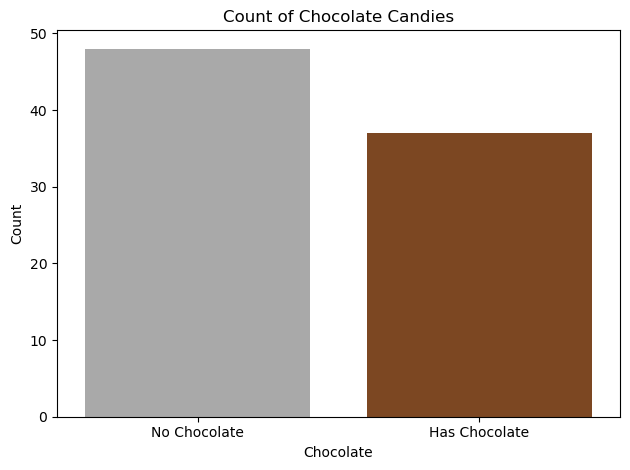

In [34]:
# Create Countplot of Chocolate Candies to Not Chocolate Candies
sns.countplot(data=df_new, x="chocolate", hue="chocolate", 
              palette={0: 'darkgrey', 1: 'saddlebrown'}, legend=False)

plt.title('Count of Chocolate Candies')
plt.xlabel('Chocolate')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Chocolate', 'Has Chocolate'])
plt.tight_layout()
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\chocolate_candies_countplot.png", dpi=300)
plt.show()


***Explain***: This visualization shows that there are about 40, of the total 85 candies observed, have chocolate. There are more candies without chocolate than candies with.

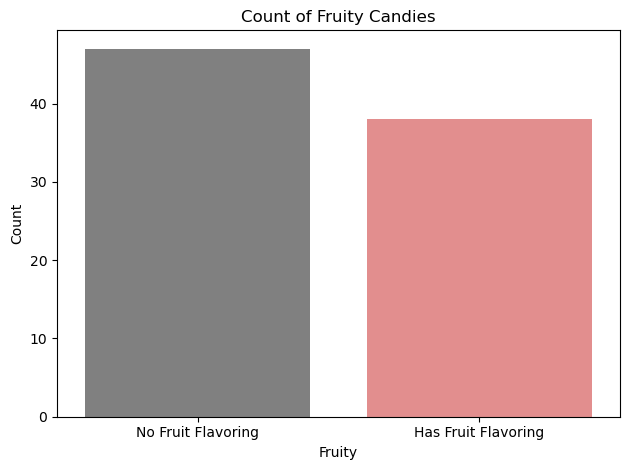

In [36]:
# Create Countplot of Fruity Candies to No Fruity Candies
sns.countplot(data=df_new, x="fruity", hue="fruity", palette={0: 'grey', 1: 'lightcoral'}, legend=False)

plt.title('Count of Fruity Candies')
plt.xlabel('Fruity')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Fruit Flavoring', 'Has Fruit Flavoring'])
plt.tight_layout()
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\fruity_candies_countplot.png", dpi=300)
plt.show()


***Explain***: This visualization shows that there are about 40 candies with fruit flavoring/are fruity of the 85 candies observed. There are more candies that are not fruity than there are candies with fruit flavoring/are fruity.

**Comparative Visualizations**

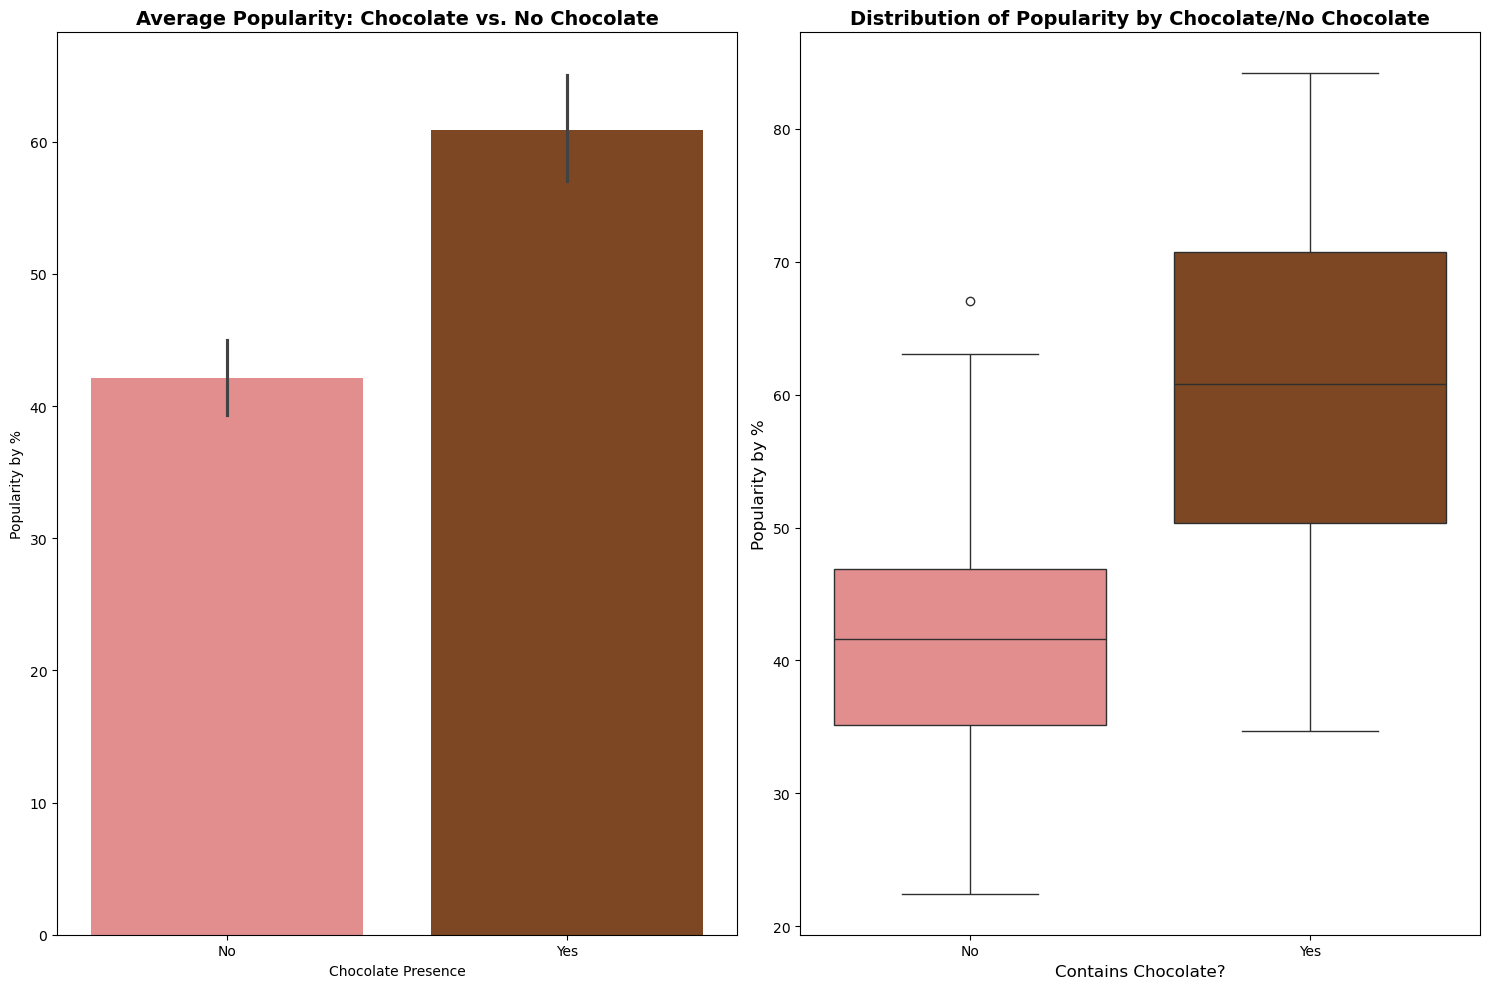

In [39]:
# Forming graphs beside each other
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

# Average WinPercentage for candies with vs. without chocolate
sns.barplot(x='chocolate', y='winpercent', hue='chocolate',
            data=df, palette={1: 'saddlebrown', 0: 'lightcoral'},
            ax=axes[0], legend=False)
axes[0].set_title('Average Popularity: Chocolate vs. No Chocolate', fontsize=14, weight='bold')
axes[0].set_xlabel('Chocolate Presence')
axes[0].set_ylabel('Popularity by %')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

# Distribution of popularity of those with chocolate and without chocolate
sns.boxplot(x='chocolate', y='winpercent', hue='chocolate',
            data=df, palette={1: 'saddlebrown', 0: 'lightcoral'},
            ax=axes[1], legend=False)
axes[1].set_title('Distribution of Popularity by Chocolate/No Chocolate', fontsize=14, weight='bold')
axes[1].set_xlabel('Contains Chocolate?', fontsize=12)
axes[1].set_ylabel('Popularity by %', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

# Showing and Saving Plots
plt.tight_layout()
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\chocolate_popularity_side_by_side.png", dpi=300)
plt.show()


In [40]:
# Filter for fruity candies with winrate greater than 65% to find outlier.
outlier_fruity = df_new[(df_new['fruity'] == 1) & (df_new['winpercent'] > 65)]

# Display the outlier
print(outlier_fruity)


   competitorname  chocolate  fruity  caramel  peanutyalmondy  nougat  \
68      Starburst          0       1        0               0       0   

    crispedricewafer  hard  bar  pluribus  sugarpercent  pricepercent  \
68                 0     0    0         1         0.151          0.22   

    winpercent   WinRateCateg SugarLevel PriceComparison  \
68   67.037628  High Win Rate        Low         Cheaper   

    sugarpercent_rounded  pricepercent_rounded  winpercent_rounded  
68                 0.151                  0.22            67.03763  


***Explain***: The visualizations compare the average popularity of chocolate/no chocolate candies with the distribution of popularity to get a good idea of the general effect of chocolate on popularity. 

From our previous data understanding, it was shown that chocolate candies tended to be more popular than those without chocolate. The visualizations show again that chocolate candies tend to be more popular than those without chocolate.

The boxplot shows that the spread of **non-chocolate** candies, however, spreads closer to the average popularity of **chocolate**. This shows that although non-chocolate candies are less popular on average, there are a good few that are just as popular as the average popular chocolate candy. In general, the **non-chocolate group** also has a **lower average popularity** than the chocolate group, and a **smaller overall distribution**, with most values clustered tighter. Interestingly, it has a **longer tail towards higher popularity**, suggesting that while most non-chocolate candies aren’t very popular, a few do stand out. In contrast, the chocolate group’s box is more **evenly distributed**, showing a more consistent range of popularity.

One of note, aka the outlier within the non-chocolate distribution, is Starburst with a 67.04% popularity percentage!

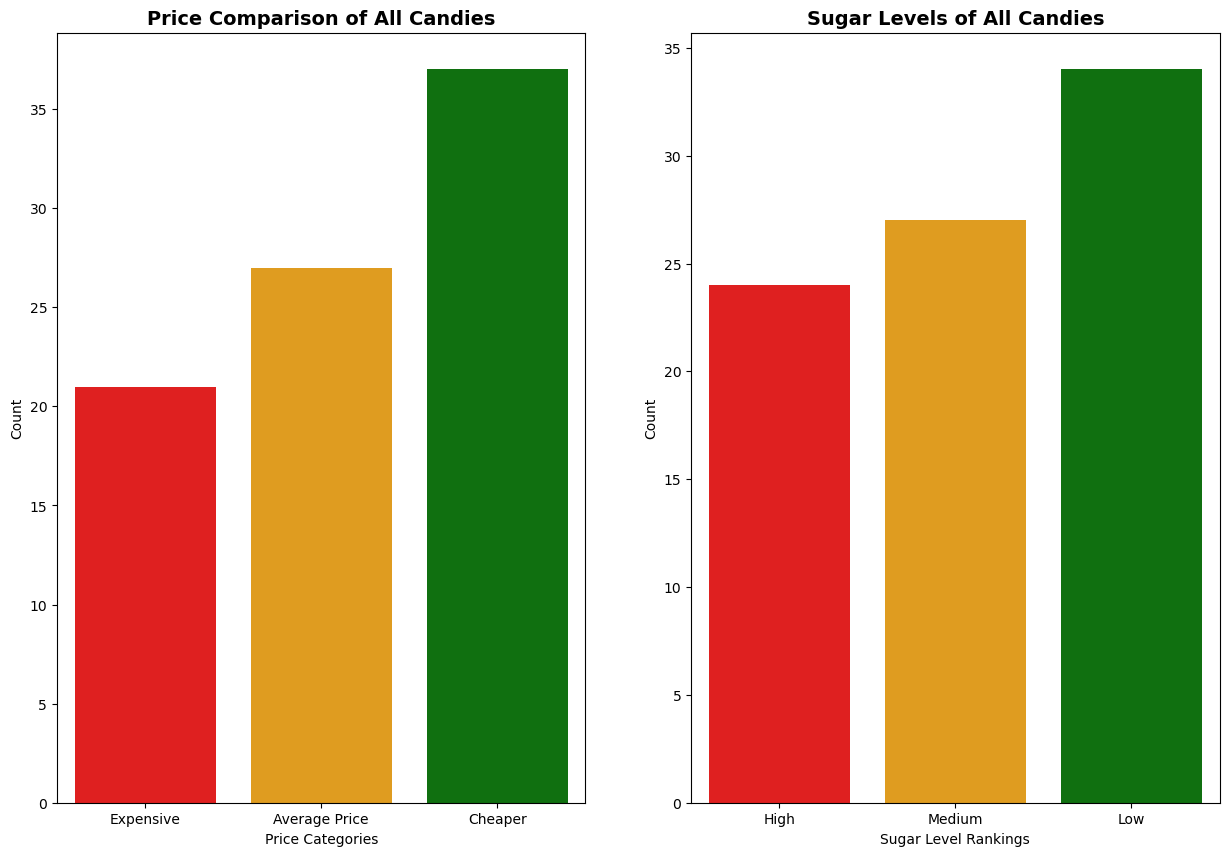

In [42]:
# Creating comparison plot for price comparison and sugar levels of all candies
fig, axes = plt.subplots(1, 2, figsize = (15,10))

# Creating countplot for price ranking
sns.countplot(data=df_new,x="PriceComparison", hue= "PriceComparison", palette={'Expensive':'red', 'Average Price': 'orange', 'Cheaper': 'green'},ax=axes[0], legend=False)
axes[0].set_title('Price Comparison of All Candies', fontsize=14, weight='bold')
axes[0].set_xlabel('Price Categories')
axes[0].set_ylabel('Count')

# Creating countplot for sugar levels.
sns.countplot(data=df_new,x="SugarLevel", hue= "SugarLevel", palette={'High':'red', 'Medium': 'orange', 'Low': 'green'},ax=axes[1],legend=False)
axes[1].set_title('Sugar Levels of All Candies', fontsize=14, weight='bold')
axes[1].set_xlabel('Sugar Level Rankings')
axes[1].set_ylabel('Count')

plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\candy_price_sugar_winrate.png", dpi=300)
plt.show()

***Explain***: This comparison of visualizations creates countplots for the created variables "Price Comparison" and "Sugar Level". This allows us to see the distribution of how many candies fall into each category. 
We can see that for the price comparison and sugar levels, most candies fall on the cheaper and less sugar-y end of all candies.

**Grouped Visualizations**

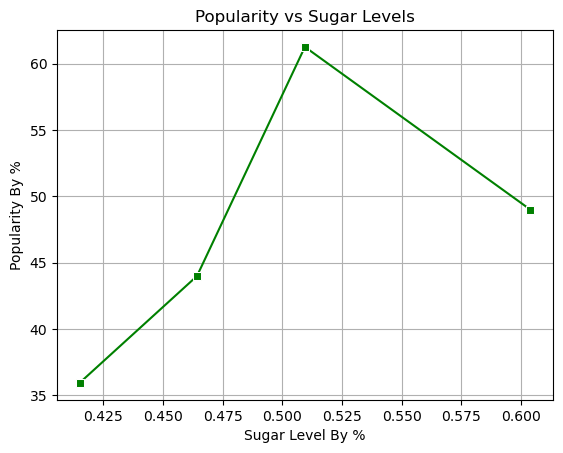

In [45]:
# Creating lineplot for popularity vs sugar levels.
sns.lineplot(data=df_categ, x='sugarpercent', y='winpercent', marker='s', color='green')
plt.title('Popularity vs Sugar Levels')
plt.xlabel('Sugar Level By %')
plt.ylabel('Popularity By %')
plt.grid(True)
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\sugar_vs_popularity_lineplot.png", dpi=300)
plt.show()

***Explain***: This visualization provides information on how the sugar level of candy affects its popularity. We can take that the average amount of sugar level within the dataset (40-50%) has the most popularity. Going past that average shows a lower popularity percentage.

**Relationship Visualizations**

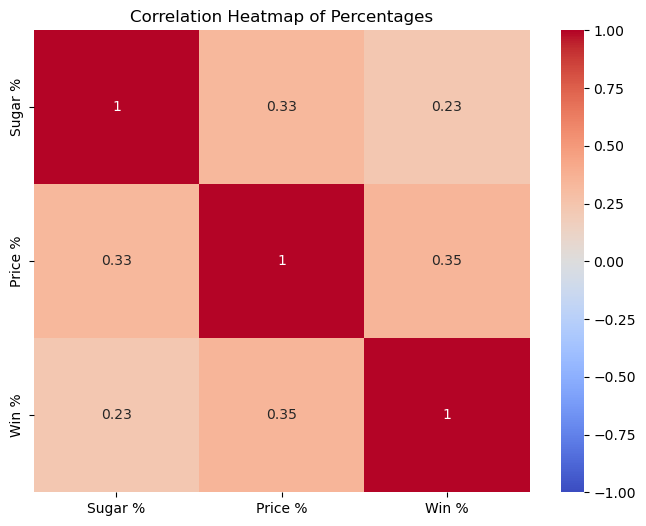

In [48]:
# Select only numeric columns
numeric_columns = ['sugarpercent', 'pricepercent', 'winpercent']
corr = df_new[numeric_columns].corr()

#Creating custom labels for clarity
custom_labels = ['Sugar %', 'Price %', 'Win %']

# Creating heatmap
plt.figure(figsize=(8, 6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticklabels(custom_labels)
ax.set_yticklabels(custom_labels)

plt.title('Correlation Heatmap of Percentages')
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\correlation_heatmap.png", dpi=300)
plt.show()

***Explain***: This visualization provides a correlation heatmap of sugar level, price level, win level. It shows that there is a weak to moderate positive relationship between Price % and Win % (~0.35), meaning that candies that are more popular might be slightly more popular, or even more popular candies are more expensive. 

Also, there is a weak positive (~0.33) correlation between Sugar % and Price %, showing that candies with more sugar tend to cost a bit more, or that higher priced candies might have more sugar.

It is good to note that the weak positive (~0.23) correlation between Sugar % and Win % means that not just sugar content effects how popular a candy is.

In [50]:
# Split the data into two groups based on chocolate or fruity presence
df_chocolate = df_new[df_new['chocolate'] == 1]  # For chocolate items
df_fruity = df_new[df_new['fruity'] == 1]        # For fruity items


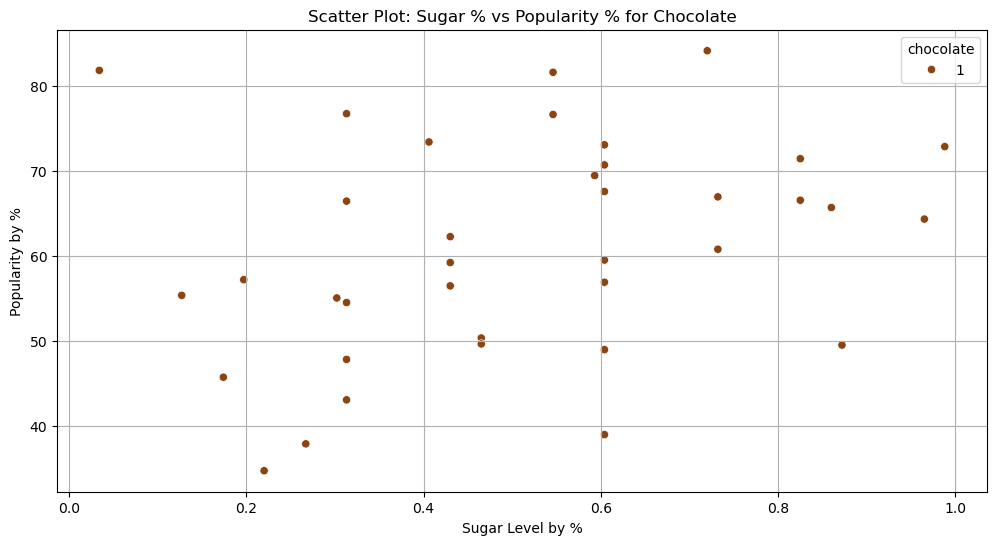

In [51]:
#Creating scatterplot for sugar percentage vs popularity percentage for chocolate.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_chocolate, x='sugarpercent', y='winpercent', hue='chocolate', palette={0: 'grey', 1: 'saddlebrown'})
plt.title('Scatter Plot: Sugar % vs Popularity % for Chocolate')
plt.xlabel('Sugar Level by %')
plt.ylabel('Popularity by %')
plt.grid(True)
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\scatter_sugar_vs_popularity_chocolate.png", dpi=300)
plt.show()

***Explain***:  This visualization provides information on the correlation between sugar levels and popularity for chocolate candies. Chocolate candies typically have sugar levels around 60%, with popularity levels reaching up to 80%.

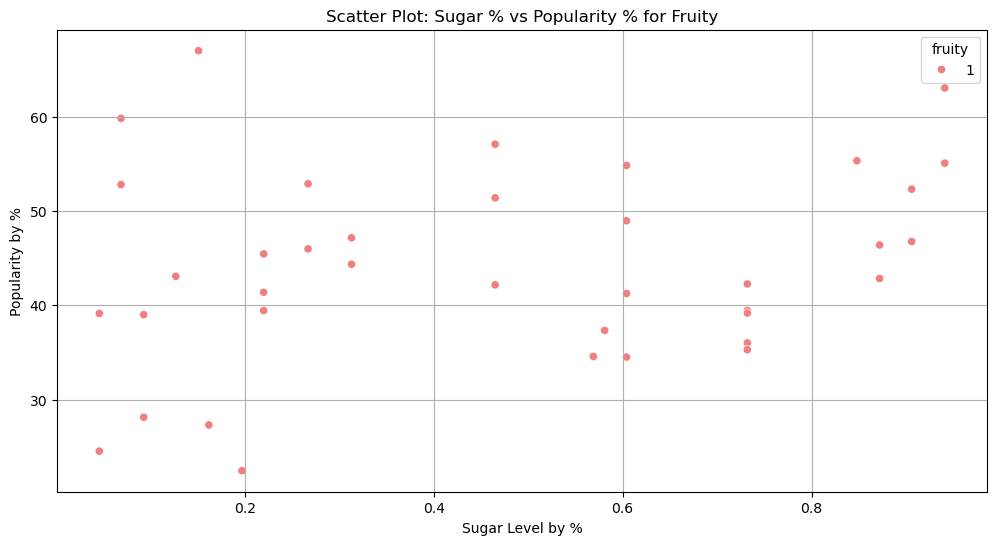

In [53]:
# #Creating scatterplot for sugar percentage vs popularity percentage for fruity candies.
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_fruity, x='sugarpercent', y='winpercent', hue='fruity', palette={0: 'grey', 1: 'lightcoral'})
plt.title('Scatter Plot: Sugar % vs Popularity % for Fruity')
plt.xlabel('Sugar Level by %')
plt.ylabel('Popularity by %')
plt.grid(True)
plt.savefig("C:\\Users\\pfmij\\In_Class_Assignments\\scatter_sugar_vs_popularity_fruity.png", dpi=300)
plt.show()

***Explain***: This visualization provides information on the correlation between sugar levels and popularity for fruity candies. The sugar levels of fruity candies generally tend to be lower than chocolate candies. Their popularity peaks around 70%. This shows that chocolate candies appear to be more popular overall, which may be linked to the fact that chocolate candies often contain higher sugar content.

#### **Conclusion/Summary:** 
This data analysis provides valuable insights into how key candy characteristics correlate with sugar content, price, and preferability. From the data, we can tell that chocolate-based products, in general, have higher sugar percentages and are more preferable in comparison to other fruity candy options.

These findings indicate a distinct relationship between flavoring choices and product characteristics, which could be helpful in making decisions about product offerings or targeting specific consumer preferences. This data analysis may allow companies to refine their understanding of consumer preferences.


#### Dataset Source (References):


FiveThirtyEight Candy Power Ranking Dataset:
["https://www.kaggle.com/datasets/fivethirtyeight/fivethirtyeight-candy-power-ranking-dataset/data"]